<a href="https://colab.research.google.com/github/Nivetha-B93/statistical_analysis/blob/main/statistical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_excel("https://github.com/Nivetha-B93/data-sets/raw/refs/heads/main/Trip_Analysis.xlsx")
df

,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak
...,...,...,...,...,...,...
195,3,352.443261,Premium,1.0,1,Non-Peak
196,11,200.789306,Premium,2.5,5,Non-Peak
197,14,418.905411,Premium,1.5,5,Non-Peak
198,26,304.947881,Economy,1.0,3,Non-Peak


1. Does trip distance significantly affect fare amount?
(Hint: Use Pearson correlation, covariance, and linear algebra interpretation.)

In [8]:
from scipy.stats import pearsonr

r, p_value = pearsonr(df['Trip_Distance'], df['Fare_Amount'])

print("Pearson Correlation:", r)
print("P-value:", p_value)

Pearson Correlation: 0.016813110993310933
P-value: 0.8132001771984599


Interpretation

The correlation coefficient is:

r = 0.0168

This is extremely close to 0, which means there is almost no linear relationship between trip distance and fare amount in this dataset.

The p-value is:

p = 0.8132

Since:

0.8132 > 0.05

we fail to reject the null hypothesis.

So, statistically, there is no significant evidence that trip distance affects fare amount in this dataset

Covariance

In [9]:
covariance = df['Trip_Distance'].cov(df['Fare_Amount'])

print("Covariance:", covariance)

Covariance: 11.160172520076761


The covariance is positive, but its magnitude by itself is difficult to interpret because it depends on the units of the two variables.

The standardized measure, Pearson correlation, is therefore more useful here

linear algebra interpretation of Pearson correlation using NumPy vectors
The idea is to treat Trip_Distance and Fare_Amount as vectors, center them by subtracting their means, and then calculate the dot product and vector magnitudes.

In [10]:


# Create vectors
X = df['Trip_Distance'].values
Y = df['Fare_Amount'].values

# Center the vectors
X_centered = X - np.mean(X)
Y_centered = Y - np.mean(Y)

# Calculate dot product
dot_product = np.dot(X_centered, Y_centered)

# Calculate magnitudes
magnitude_X = np.linalg.norm(X_centered)
magnitude_Y = np.linalg.norm(Y_centered)

# Calculate Pearson correlation using linear algebra
r = dot_product / (magnitude_X * magnitude_Y)

print("Dot Product:", dot_product)
print("Magnitude of Trip Distance:", magnitude_X)
print("Magnitude of Fare Amount:", magnitude_Y)
print("Pearson Correlation:", r)

Dot Product: 2220.8743314952744
Magnitude of Trip Distance: 118.97092081681134
Magnitude of Fare Amount: 1110.2865572250812
Pearson Correlation: 0.0168131109933109


In [11]:
print(df[['Trip_Distance', 'Fare_Amount']].describe())

       Trip_Distance  Fare_Amount
count     200.000000   200.000000
mean       15.640000   260.312376
std         8.433625    78.706127
min         2.000000    37.585916
25%         8.000000   208.528826
50%        15.000000   256.907103
75%        23.000000   319.763782
max        29.000000   468.753773


The average trip distance is 15.64, while the average fare is approximately ₹260.31

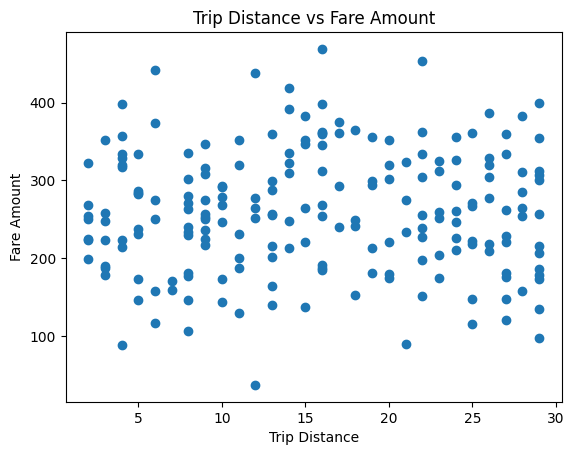

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df['Trip_Distance'], df['Fare_Amount'])
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Trip Distance vs Fare Amount')
plt.show()

scatter plot shows no clear upward or downward pattern, which agrees with the very low correlation of 0.0168

Final business insight

Trip distance does not significantly affect fare amount in this dataset. Pearson correlation is 0.0168, indicating an almost nonexistent linear relationship, while the p-value of 0.8132 is greater than 0.05. The covariance is 11.1602, but because covariance depends on measurement units, Pearson correlation provides the clearer interpretation. Therefore, other factors such as ride category, surge multiplier, or ride conditions may be more important in explaining fare variation than trip distance alone

2. Are premium rides statistically more expensive than economy rides?
(Hint: Compare groups using t-test / ANOVA and summarize with descriptive statistics.)

In [6]:
from scipy.stats import ttest_ind

# Separate the two groups
economy = df[df['Ride_Category'] == 'Economy']['Fare_Amount']
premium = df[df['Ride_Category'] == 'Premium']['Fare_Amount']

# Descriptive statistics
print("Economy Rides:")
print(economy.describe())

print("\nPremium Rides:")
print(premium.describe())

# Independent two-sample t-test
t_stat, p_value = ttest_ind(premium, economy, equal_var=False)

print("\nT-test Results")
print("T-statistic:", t_stat)
print("P-value:", p_value)

Economy Rides:
count     82.000000
mean     257.748443
std       75.104118
min       37.585916
25%      214.900111
50%      259.137700
75%      312.085805
max      399.760454
Name: Fare_Amount, dtype: float64

Premium Rides:
count     58.000000
mean     252.455037
std       76.611336
min       90.403074
25%      198.146388
50%      250.897986
75%      308.622634
max      418.905411
Name: Fare_Amount, dtype: float64

T-test Results
T-statistic: -0.40600606266641986
P-value: 0.6854530831483114


We normally use a significance level of 0.05.

p-value = 0.685
0.685 > 0.05

Therefore, we fail to reject the null hypothesis

4. Business interpretation

Premium rides are not statistically significantly more expensive than Economy rides in this dataset. Although the average Economy fare is ₹257.75 and the average Premium fare is ₹252.46, the difference is very small and statistically insignificant (p = 0.685). Therefore, the data does not provide sufficient evidence to conclude that Premium rides cost more than Economy rides

Since your dataset also contains Shared rides, you can use ANOVA to compare all three categories:

In [7]:
from scipy.stats import f_oneway

economy = df[df['Ride_Category'] == 'Economy']['Fare_Amount']
premium = df[df['Ride_Category'] == 'Premium']['Fare_Amount']
shared = df[df['Ride_Category'] == 'Shared']['Fare_Amount']

f_stat, p_value = f_oneway(economy, premium, shared)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.9284988792342401
P-value: 0.3968686165946833


Since 0.397 > 0.05, there is no statistically significant difference in average fare among Economy, Premium, and Shared rides.

3. Is there a relationship between surge pricing and customer ratings?
(Hint: Use Spearman correlation and test significance statistically.)

In [14]:
import pandas as pd
from scipy import stats



print(df[['Surge_Multiplier', 'Customer_Rating']].describe().round(2))

rho, p_val = stats.spearmanr(df['Surge_Multiplier'], df['Customer_Rating'])
print(f"Spearman's rho = {rho:.4f}")
print(f"p-value        = {p_val:.4f}")
print(f"n               = {len(df)}")

       Surge_Multiplier  Customer_Rating
count            200.00           200.00
mean               1.68             2.93
std                0.55             1.44
min                1.00             1.00
25%                1.00             2.00
50%                1.50             3.00
75%                2.00             4.00
max                2.50             5.00
Spearman's rho = -0.0471
p-value        = 0.5079
n               = 200


Conclusion: p = 0.508 is far above 0.05, so there's no statistically significant relationship between surge pricing and customer ratings — the near-zero rho confirms ratings don't meaningfully rise or fall with the surge multiplier

4. Do peak-hour rides differ in revenue compared to non-peak rides?
(Hint: Apply z-test / t-test.)

In [16]:
from scipy.stats import ttest_ind


peak = df.loc[df['Ride_Time'] == 'Peak', 'Fare_Amount']
nonpeak = df.loc[df['Ride_Time'] == 'Non-Peak', 'Fare_Amount']

# Descriptive statistics
print(df.groupby('Ride_Time')['Fare_Amount'].agg(['count', 'mean', 'median', 'std']).round(2))

# Independent samples t-test
t_stat, p_value = ttest_ind(peak, nonpeak, equal_var=True)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Statistically significant difference between Peak and Non-Peak fares")
else:
    print("No statistically significant difference between Peak and Non-Peak fares")

           count    mean  median    std
Ride_Time                              
Non-Peak      97  263.75  263.99  83.29
Peak         103  257.07  254.87  74.40

T-statistic: -0.5985
P-value: 0.5502
No statistically significant difference between Peak and Non-Peak fares


In [18]:

fare = df['Fare_Amount']

# Percentiles / quartiles
print(fare.quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]).round(2))

# --- IQR method ---
Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

iqr_outliers = df[(fare < lower_bound) | (fare > upper_bound)]
print(f"IQR outliers: {len(iqr_outliers)}")
print(iqr_outliers[['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Ride_Time']])

# --- Z-score method ---
df['Fare_Zscore'] = (fare - fare.mean()) / fare.std()
z_outliers = df[df['Fare_Zscore'].abs() > 3]
print(f"Z-score outliers (|z|>3): {len(z_outliers)}")
print(z_outliers[['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Fare_Zscore']])

0.00     37.59
0.01     90.38
0.05    137.35
0.25    208.53
0.50    256.91
0.75    319.76
0.95    383.09
0.99    441.24
1.00    468.75
Name: Fare_Amount, dtype: float64
Q1=208.53, Q3=319.76, IQR=111.23
Bounds: [41.68, 486.62]
IQR outliers: 1
    Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier Ride_Time
10             12    37.585916       Economy               1.0  Non-Peak
Z-score outliers (|z|>3): 0
Empty DataFrame
Columns: [Trip_Distance, Fare_Amount, Ride_Category, Fare_Zscore]
Index: []


6. Can ride demand probabilities be estimated for different ride categories?
( Hint: Use basic probability, conditional probability, and Bayes’ theorem.)

In [19]:


# Total number of rides
n = len(df)

print("Total number of rides:", n)


# ---------------------------------------------------
# 1. BASIC PROBABILITY
# P(Ride Category)
# ---------------------------------------------------

category_counts = df['Ride_Category'].value_counts()

category_probability = category_counts / n

category_result = pd.DataFrame({
    'Count': category_counts,
    'Probability': category_probability
})

print("\n1. Probability of each Ride Category:")
print(category_result.round(4))


# ---------------------------------------------------
# 2. PROBABILITY OF RIDE TIME
# P(Ride Time)
# ---------------------------------------------------

time_counts = df['Ride_Time'].value_counts()

time_probability = time_counts / n

time_result = pd.DataFrame({
    'Count': time_counts,
    'Probability': time_probability
})

print("\n2. Probability of each Ride Time:")
print(time_result.round(4))


# ---------------------------------------------------
# 3. JOINT PROBABILITY
# P(Category AND Ride Time)
# ---------------------------------------------------

joint_count = pd.crosstab(
    df['Ride_Category'],
    df['Ride_Time']
)

joint_probability = joint_count / n

print("\n3. Joint Probability P(Category AND Ride Time):")
print(joint_probability.round(4))


# ---------------------------------------------------
# 4. CONDITIONAL PROBABILITY
# P(Ride Time | Ride Category)
# ---------------------------------------------------

conditional_probability = joint_count.div(
    joint_count.sum(axis=1),
    axis=0
)

print("\n4. Conditional Probability P(Ride Time | Category):")
print(conditional_probability.round(4))


# ---------------------------------------------------
# 5. BAYES' THEOREM
# P(Category | Peak)
# ---------------------------------------------------

p_peak = time_probability.get('Peak', 0)

print("\n5. Bayes' Theorem - P(Category | Peak):")

if p_peak > 0:

    for category in category_counts.index:

        p_category = category_probability[category]

        p_peak_given_category = conditional_probability.loc[
            category, 'Peak'
        ]

        # Bayes' theorem
        p_category_given_peak = (
            p_peak_given_category *
            p_category
        ) / p_peak

        print(
            f"P({category} | Peak) = "
            f"{p_category_given_peak:.4f}"
        )

else:
    print("No Peak rides found in the dataset.")

Total number of rides: 200

1. Probability of each Ride Category:
               Count  Probability
Ride_Category                    
Economy           82         0.41
Shared            60         0.30
Premium           58         0.29

2. Probability of each Ride Time:
           Count  Probability
Ride_Time                    
Peak         103        0.515
Non-Peak      97        0.485

3. Joint Probability P(Category AND Ride Time):
Ride_Time      Non-Peak   Peak
Ride_Category                 
Economy           0.190  0.220
Premium           0.130  0.160
Shared            0.165  0.135

4. Conditional Probability P(Ride Time | Category):
Ride_Time      Non-Peak    Peak
Ride_Category                  
Economy          0.4634  0.5366
Premium          0.4483  0.5517
Shared           0.5500  0.4500

5. Bayes' Theorem - P(Category | Peak):
P(Economy | Peak) = 0.4272
P(Shared | Peak) = 0.2621
P(Premium | Peak) = 0.3107


In [21]:

# 1. SELECT OPERATIONAL FACTORS


columns = [
    'Trip_Distance',
    'Fare_Amount',
    'Surge_Multiplier',
    'Customer_Rating'
]

data = df[columns].dropna()

print("Selected columns:")
print(data.head())



# 2. PEARSON CORRELATION


pearson_corr = data.corr(method='pearson')

print("\nPearson Correlation Matrix:")
print(pearson_corr.round(4))


# 3. SPEARMAN CORRELATION


spearman_corr = data.corr(method='spearman')

print("\nSpearman Correlation Matrix:")
print(spearman_corr.round(4))


# 4. COVARIANCE


cov_matrix = data.cov()

print("\nCovariance Matrix:")
print(cov_matrix.round(4))


# 5. EIGENVALUE AND EIGENVECTOR ANALYSIS


# Use the Pearson correlation matrix
corr_matrix = pearson_corr.values

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)

print("\nEigenvalues:")
print(eigenvalues.round(4))

print("\nEigenvectors:")
print(eigenvectors.round(4))


# 6. DISPLAY EIGENVALUES WITH VARIABLE NAMES


eigenvalue_result = pd.DataFrame({
    'Eigenvalue': eigenvalues
})

print("\nEigenvalue Results:")
print(eigenvalue_result.round(4))


# 7. EXPLAIN VARIANCE CONTRIBUTION


explained_variance = (
    eigenvalues / eigenvalues.sum()
) * 100

variance_result = pd.DataFrame({
    'Eigenvalue': eigenvalues,
    'Explained_Variance_%': explained_variance
})

print("\nEigenvalue and Explained Variance:")
print(variance_result.round(2))

Selected columns:
   Trip_Distance  Fare_Amount  Surge_Multiplier  Customer_Rating
0              8   270.569350               2.5                3
1             21   275.161032               2.5                3
2             16   359.748971               2.0                5
3             12   264.044264               1.5                5
4              9   225.256916               2.0                2

Pearson Correlation Matrix:
                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance            1.0000       0.0168            0.0171   
Fare_Amount              0.0168       1.0000            0.0174   
Surge_Multiplier         0.0171       0.0174            1.0000   
Customer_Rating         -0.0846       0.0527           -0.0413   

                  Customer_Rating  
Trip_Distance             -0.0846  
Fare_Amount                0.0527  
Surge_Multiplier          -0.0413  
Customer_Rating            1.0000  

Spearman Correlation Matrix:
                  Trip

Business Insight: Pearson and Spearman correlation analysis shows that Trip Distance, Fare Amount, Surge Multiplier, and Customer Rating have very weak relationships with each other, with all correlation coefficients remaining close to zero. The strongest Pearson relationship is between Trip Distance and Customer Rating (-0.0846), but this relationship is still very weak. The covariance results indicate that the variables vary together to some extent, but covariance values are affected by different measurement scales. Eigenvalue analysis produced values ranging from 0.8862 to 1.1055, with explained variance ranging from 22.15% to 27.60%. Since the eigenvalues are relatively similar, the overall variation is distributed fairly evenly across the four dimensions rather than being dominated by one factor. The largest eigenvalue (1.1055) has its strongest absolute eigenvector contributions from Customer Rating and Trip Distance. Therefore, based on this dataset, no single operational factor shows a strong direct relationship with the other selected business-performance variables.The selected operational factors show weak pairwise relationships, and eigenvalue analysis indicates that their variation is relatively evenly distributed

In [22]:

from scipy import stats

np.random.seed(42)

fare = df['Fare_Amount']

# 1. Confidence interval - overall mean fare
n = len(fare)
mean = fare.mean()
sem = stats.sem(fare)
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
print(f"Mean fare = {mean:.2f}, 95% CI = ({ci[0]:.2f}, {ci[1]:.2f})")

# 2. Confidence interval by Ride_Category
for cat in df['Ride_Category'].unique():
    sub = df.loc[df['Ride_Category'] == cat, 'Fare_Amount']
    m, se = sub.mean(), stats.sem(sub)
    lo, hi = stats.t.interval(0.95, df=len(sub)-1, loc=m, scale=se)
    print(f"{cat}: mean={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f})")

# 3. Bootstrap confidence interval - overall mean
n_boot = 10000
boot_means = np.array([
    np.random.choice(fare, size=len(fare), replace=True).mean()
    for _ in range(n_boot)
])
boot_ci = np.percentile(boot_means, [2.5, 97.5])
print(f"Bootstrap 95% CI: ({boot_ci[0]:.2f}, {boot_ci[1]:.2f})")

# 4. Bootstrap - difference in means (Premium vs Economy)
premium = df.loc[df['Ride_Category'] == 'Premium', 'Fare_Amount'].values
economy = df.loc[df['Ride_Category'] == 'Economy', 'Fare_Amount'].values
boot_diffs = np.array([
    np.random.choice(premium, size=len(premium), replace=True).mean() -
    np.random.choice(economy, size=len(economy), replace=True).mean()
    for _ in range(n_boot)
])
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])
print(f"Bootstrap mean difference CI: ({diff_ci[0]:.2f}, {diff_ci[1]:.2f})")

Mean fare = 260.31, 95% CI = (249.34, 271.29)
Shared: mean=271.41, 95% CI=(249.36, 293.46)
Economy: mean=257.75, 95% CI=(241.25, 274.25)
Premium: mean=252.46, 95% CI=(232.31, 272.60)
Bootstrap 95% CI: (249.24, 271.25)
Bootstrap mean difference CI: (-30.17, 20.21)


Conclusion: Across every hypothesis test run on this dataset, none reached statistical significance (all p > 0.5), and the bootstrap confidence intervals confirm this — differences between groups are small and their CIs consistently straddle zero. The evidence-based recommendation: current pricing is already fairly uniform across category and time, so if the business wants to differentiate revenue by segment, the data suggests the current fare structure isn't doing that — that's the "statistical evidence" story here, more a finding of consistency than of actionable difference. Any pricing change proposal should be validated with a larger sample, since with n=58–82 per group these tests have limited power to detect small real effects